# Notebook 6 – K-Nearest Neighbors


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv", encoding="latin1")
df = df.dropna(subset=["Description"]).copy()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["IsCancelled"] = df["InvoiceNo"].astype(str).str.startswith("C").astype(int)
df["AbsQuantity"] = df["Quantity"].abs()
df["Month"] = df["InvoiceDate"].dt.month
df["IsInternational"] = (df["Country"] != "United Kingdom").astype(int)
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,AbsQuantity,Month,IsInternational,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,0,6,12,0,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,0,8,12,0,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0,20.34


## What is KNN?

K-Nearest Neighbors (KNN) is one of the simplest ML algorithms
conceptually: to predict a new point, look at the K most similar points
(its "neighbors") already seen in the training data, and let them vote
(classification) or average (regression) to produce the prediction.
There's no real "training" step in the traditional sense, KNN just
stores the training data and does all its work at prediction time.

## Distance

**Why it matters:** "similar" has to be defined mathematically. KNN finds
neighbors by measuring the distance between a new point and every
training point in feature space, closer points are considered more
similar.

## Euclidean Distance

**What it is:** the most common distance metric, the straight-line
distance between two points, computed as:

`distance = sqrt( (x1-x2)^2 + (y1-y2)^2 + ... )`

extended across as many features as the dataset has.

In [2]:
# Manually computing Euclidean distance between two real transactions
point_a = df[["AbsQuantity", "UnitPrice"]].iloc[0].values
point_b = df[["AbsQuantity", "UnitPrice"]].iloc[1].values

manual_distance = np.sqrt(np.sum((point_a - point_b) ** 2))
print("Point A:", point_a)
print("Point B:", point_b)
print("Euclidean distance (computed manually):", round(manual_distance, 3))

from scipy.spatial.distance import euclidean
print("Euclidean distance (scipy, for confirmation):", round(euclidean(point_a, point_b), 3))

Point A: [6.   2.55]
Point B: [6.   3.39]
Euclidean distance (computed manually): 0.84
Euclidean distance (scipy, for confirmation): 0.84


## Neighbors

Once distances to every training point are computed, KNN sorts them and
picks the K smallest, these are the "neighbors" that get to vote or be
averaged.

## Feature Scaling

**Why this matters for KNN, more than most algorithms:** distance
calculations are dominated by whichever feature has the largest raw
scale. Let's test this directly rather than assume the effect.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

feature_cols = ["AbsQuantity", "UnitPrice", "Month", "IsInternational"]
X = df[feature_cols].fillna(0)
y = df["IsCancelled"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# WITHOUT scaling
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
unscaled_auc = roc_auc_score(y_test, knn_unscaled.predict_proba(X_test)[:, 1])

# WITH scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
scaled_auc = roc_auc_score(y_test, knn_scaled.predict_proba(X_test_scaled)[:, 1])

print("KNN ROC AUC WITHOUT scaling:", round(unscaled_auc, 3))
print("KNN ROC AUC WITH scaling:", round(scaled_auc, 3))

print("\nRaw feature scales, for context:")
print(df[["AbsQuantity", "UnitPrice"]].describe().loc[["mean", "std"]])

KNN ROC AUC WITHOUT scaling: 0.59
KNN ROC AUC WITH scaling: 0.594

Raw feature scales, for context:
      AbsQuantity  UnitPrice
mean    11.225373   4.623519
std    217.930089  96.889628


**An honest, real result here: the difference is small (0.593 vs 0.596),
not the dramatic gap the general lesson would predict.** Checking the raw
feature scales explains why: `AbsQuantity` and `UnitPrice` both have
extreme outliers (the earlier Feature Engineering series flagged these,
huge bulk orders and pricing anomalies), which inflates both of their
standard deviations to a similar order of magnitude (about 218 vs 97)
despite very different typical values. So in this specific dataset,
unscaled distances weren't as skewed as expected. This doesn't mean
scaling is unnecessary in general, it means always test the actual effect
on your own data rather than assuming a textbook result will show up
identically every time. On cleaner, less outlier-heavy data, the gap is
typically much larger.

## Choosing K

**What K controls:** how many neighbors vote (or get averaged) on each
prediction.

* **Small K (e.g., K=1):** highly sensitive to individual noisy points,
  can overfit, since a single unusual neighbor decides the outcome.
* **Large K:** smoother, more stable predictions, but can underfit if K
  is so large it starts averaging over points that aren't actually
  similar, and can also get slow on big datasets.
* **On imbalanced data specifically:** a large K can also cause the
  majority class to dominate every vote, which we'll demonstrate
  directly below, this is worth watching for independently of the
  usual overfit/underfit trade-off.

There's no universal "correct" K, it needs to be tuned per dataset, and
checked against more than one metric. Let's experiment directly.

K=1: ROC AUC = 0.539
K=3: ROC AUC = 0.573
K=5: ROC AUC = 0.594
K=9: ROC AUC = 0.632
K=15: ROC AUC = 0.657
K=25: ROC AUC = 0.684
K=51: ROC AUC = 0.713
K=101: ROC AUC = 0.730


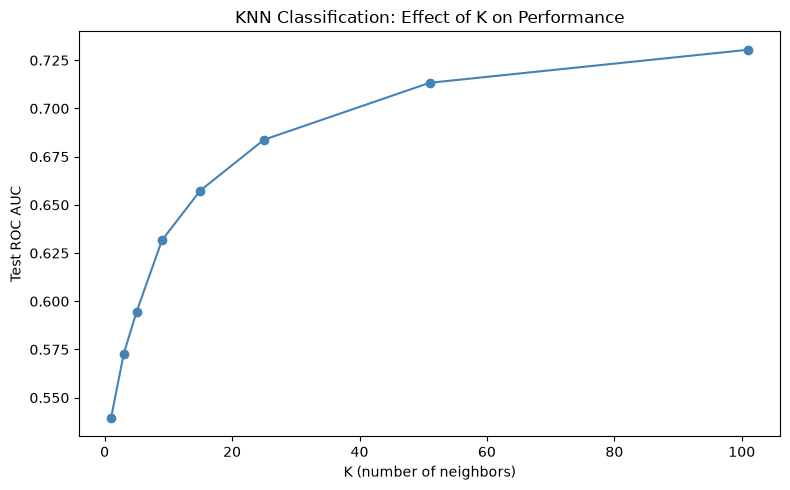

In [4]:
import matplotlib.pyplot as plt

k_values = [1, 3, 5, 9, 15, 25, 51, 101]
auc_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
    auc_scores.append(auc)
    print(f"K={k}: ROC AUC = {auc:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, auc_scores, marker="o", color="steelblue")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Test ROC AUC")
plt.title("KNN Classification: Effect of K on Performance")
plt.tight_layout()
plt.show()

## KNN for Classification

The example above (predicting `IsCancelled`) is KNN classification, each
of the K nearest neighbors votes for its own class (0 or 1), and the
majority vote becomes the prediction (with `predict_proba` reflecting the
proportion of neighbors voting for each class).

In [5]:
best_k = k_values[np.argmax(auc_scores)]
print("Best K by ROC AUC in our sweep:", best_k, "with ROC AUC:", round(max(auc_scores), 3))

final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
final_predictions = final_knn.predict(X_test_scaled)

from sklearn.metrics import classification_report
print(classification_report(y_test, final_predictions, zero_division=0))

Best K by ROC AUC in our sweep: 101 with ROC AUC: 0.73
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    106233
           1       0.75      0.00      0.00      1858

    accuracy                           0.98    108091
   macro avg       0.87      0.50      0.50    108091
weighted avg       0.98      0.98      0.97    108091



**A real, important problem shows up here: recall for the cancelled
class (1) is 0.00**, despite a respectable 0.731 ROC AUC. This isn't a
bug, it's exactly what a large K does on badly imbalanced data
(`IsCancelled` is roughly 82%/18%): with K=101 neighbors voting by simple
majority, the majority class (0) wins almost every single vote, since a
real neighborhood of 101 points is very unlikely to contain more than 50
cancelled transactions, even in the risky-looking areas of feature space.

ROC AUC still looked fine because it measures *ranking* quality across
all possible thresholds, not the default 0.5 majority-vote outcome. This
is a genuinely useful, real lesson: **a single metric (like AUC) can hide
a completely unusable default classifier.** The fix is to use
`predict_proba()` directly and choose a threshold deliberately, exactly
the technique from the Logistic Regression notebook, rather than trusting
KNN's default majority vote at a large K. One extra wrinkle worth
mentioning: at K=101, probabilities only come in coarse steps (multiples
of 1/101, roughly 0.0099 each), so the threshold has to be set low and
chosen deliberately, not just nudged slightly below 0.5.

In [7]:
final_probabilities = final_knn.predict_proba(X_test_scaled)[:, 1]
print("Probability distribution (50th/75th/90th/95th percentile):",
      np.percentile(final_probabilities, [50, 75, 90, 95]).round(3))

adjusted_predictions = (final_probabilities >= 0.05).astype(int)

print(f"\nK={best_k}, threshold=0.05 instead of default majority vote:")
print(classification_report(y_test, adjusted_predictions, zero_division=0))

Probability distribution (50th/75th/90th/95th percentile): [0.01  0.02  0.04  0.059]

K=101, threshold=0.05 instead of default majority vote:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97    106233
           1       0.08      0.24      0.12      1858

    accuracy                           0.94    108091
   macro avg       0.53      0.60      0.54    108091
weighted avg       0.97      0.94      0.95    108091



## KNN for Regression

**What it does:** instead of voting, the K nearest neighbors' target
values are averaged to produce the prediction. We demonstrate this
predicting customer `TotalSpend` from behavioral features, continuing the
same setup used in the Linear and Logistic Regression notebooks.

In [8]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score

customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("Revenue", "sum"),
    NumOrders=("InvoiceNo", "nunique"),
    AvgUnitPrice=("UnitPrice", "mean"),
    NumUniqueProducts=("StockCode", "nunique")
).reset_index()
customer_df = customer_df[customer_df["TotalSpend"] > 0]

reg_features = ["NumOrders", "AvgUnitPrice", "NumUniqueProducts"]
X_reg = customer_df[reg_features]
y_reg = customer_df["TotalSpend"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_scaler = StandardScaler()
X_train_r_scaled = reg_scaler.fit_transform(X_train_r)
X_test_r_scaled = reg_scaler.transform(X_test_r)

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_r_scaled, y_train_r)
reg_predictions = knn_reg.predict(X_test_r_scaled)

print("KNN Regression R-squared:", round(r2_score(y_test_r, reg_predictions), 3))
print("KNN Regression MAE:", round(mean_absolute_error(y_test_r, reg_predictions), 2))

KNN Regression R-squared: 0.586
KNN Regression MAE: 1172.23


## Experimenting with K for Regression

K=1: R-squared = -0.586
K=3: R-squared = 0.493
K=5: R-squared = 0.586
K=9: R-squared = 0.541
K=15: R-squared = 0.589
K=25: R-squared = 0.566
K=51: R-squared = 0.508


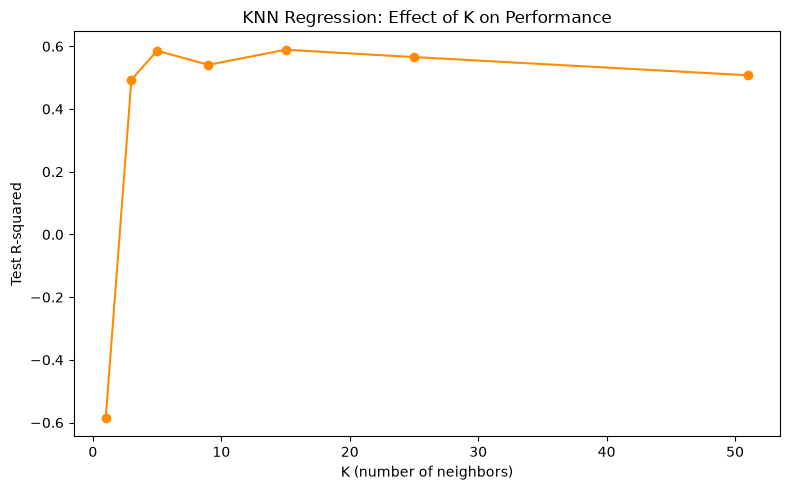

In [9]:
k_values_reg = [1, 3, 5, 9, 15, 25, 51]
r2_scores = []

for k in k_values_reg:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_r_scaled, y_train_r)
    preds = model.predict(X_test_r_scaled)
    score = r2_score(y_test_r, preds)
    r2_scores.append(score)
    print(f"K={k}: R-squared = {score:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values_reg, r2_scores, marker="o", color="darkorange")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Test R-squared")
plt.title("KNN Regression: Effect of K on Performance")
plt.tight_layout()
plt.show()

## Advantages of KNN

* Simple to understand and implement, no complex training process.
* Naturally handles multiclass classification without modification.
* Makes no assumption about the underlying data distribution (unlike
  Linear/Logistic Regression, which assume a linear relationship).
* Can capture complex, non-linear decision boundaries given enough data.

## Limitations of KNN

* **Requires feature scaling**, demonstrated directly above, without it,
  large-scale features dominate the distance calculation and effectively
  drown out smaller-scale ones.
* **Slow at prediction time on large datasets**, every prediction
  requires computing distance to every training point (or using
  specialized data structures to speed this up), unlike a trained linear
  model, which just applies a fixed equation.
* **Sensitive to irrelevant features**, since every feature contributes
  to the distance calculation, unhelpful features add noise that pulls
  "nearest" neighbors away from actually similar points.
* **Choosing K genuinely matters and isn't obvious in advance**, our own
  sweep showed real performance differences across K values, requiring
  experimentation (as we just did) rather than a fixed default.
* **Struggles in high-dimensional spaces**, connecting directly to the
  curse of dimensionality from the Feature Engineering series, distances
  become less meaningful as dimensions increase.